In [1]:
import os
from dotenv import load_dotenv, find_dotenv

# Corrected import paths:
from src.workflow_manager import build_seal_rag_graph
from src.other_rags.self_rag import get_self_rag_graph
from src.other_rags.basic_rag import get_basic_rag_graph
from src.other_rags.crag import get_crag_graph
from src.other_rags.adaptive_rag import get_adaptive_rag_graph
# If these files don't exist, comment them out
# from src.rags.crag import get_crag_graph
# from src.rags.basic_rag import get_basic_rag_graph

# Automatically find and load the .env file
#dotenv_path = find_dotenv()
load_dotenv("./.env")

# Toggle between graphs here:
graph = build_seal_rag_graph()
#graph = get_self_rag_graph()
#graph= get_crag_graph()
#graph = get_basic_rag_graph()
#graph = get_adaptive_rag_graph()

print("done")

/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/8g/yk7b34915s1b5qdl5nc6twm40000gn/T/ipykernel_88941/3963867917.py:6: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from src.other_rags.self_rag import get_self_rag_graph
/opt/homebrew/anaconda3/envs/langgraph_v

done


/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  warnings.warn(
/opt/homebrew/anaconda3/envs/langgraph_v1/lib/python3.11/site-packages/langchain_openai/chat_models/base.py:1844: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or speci

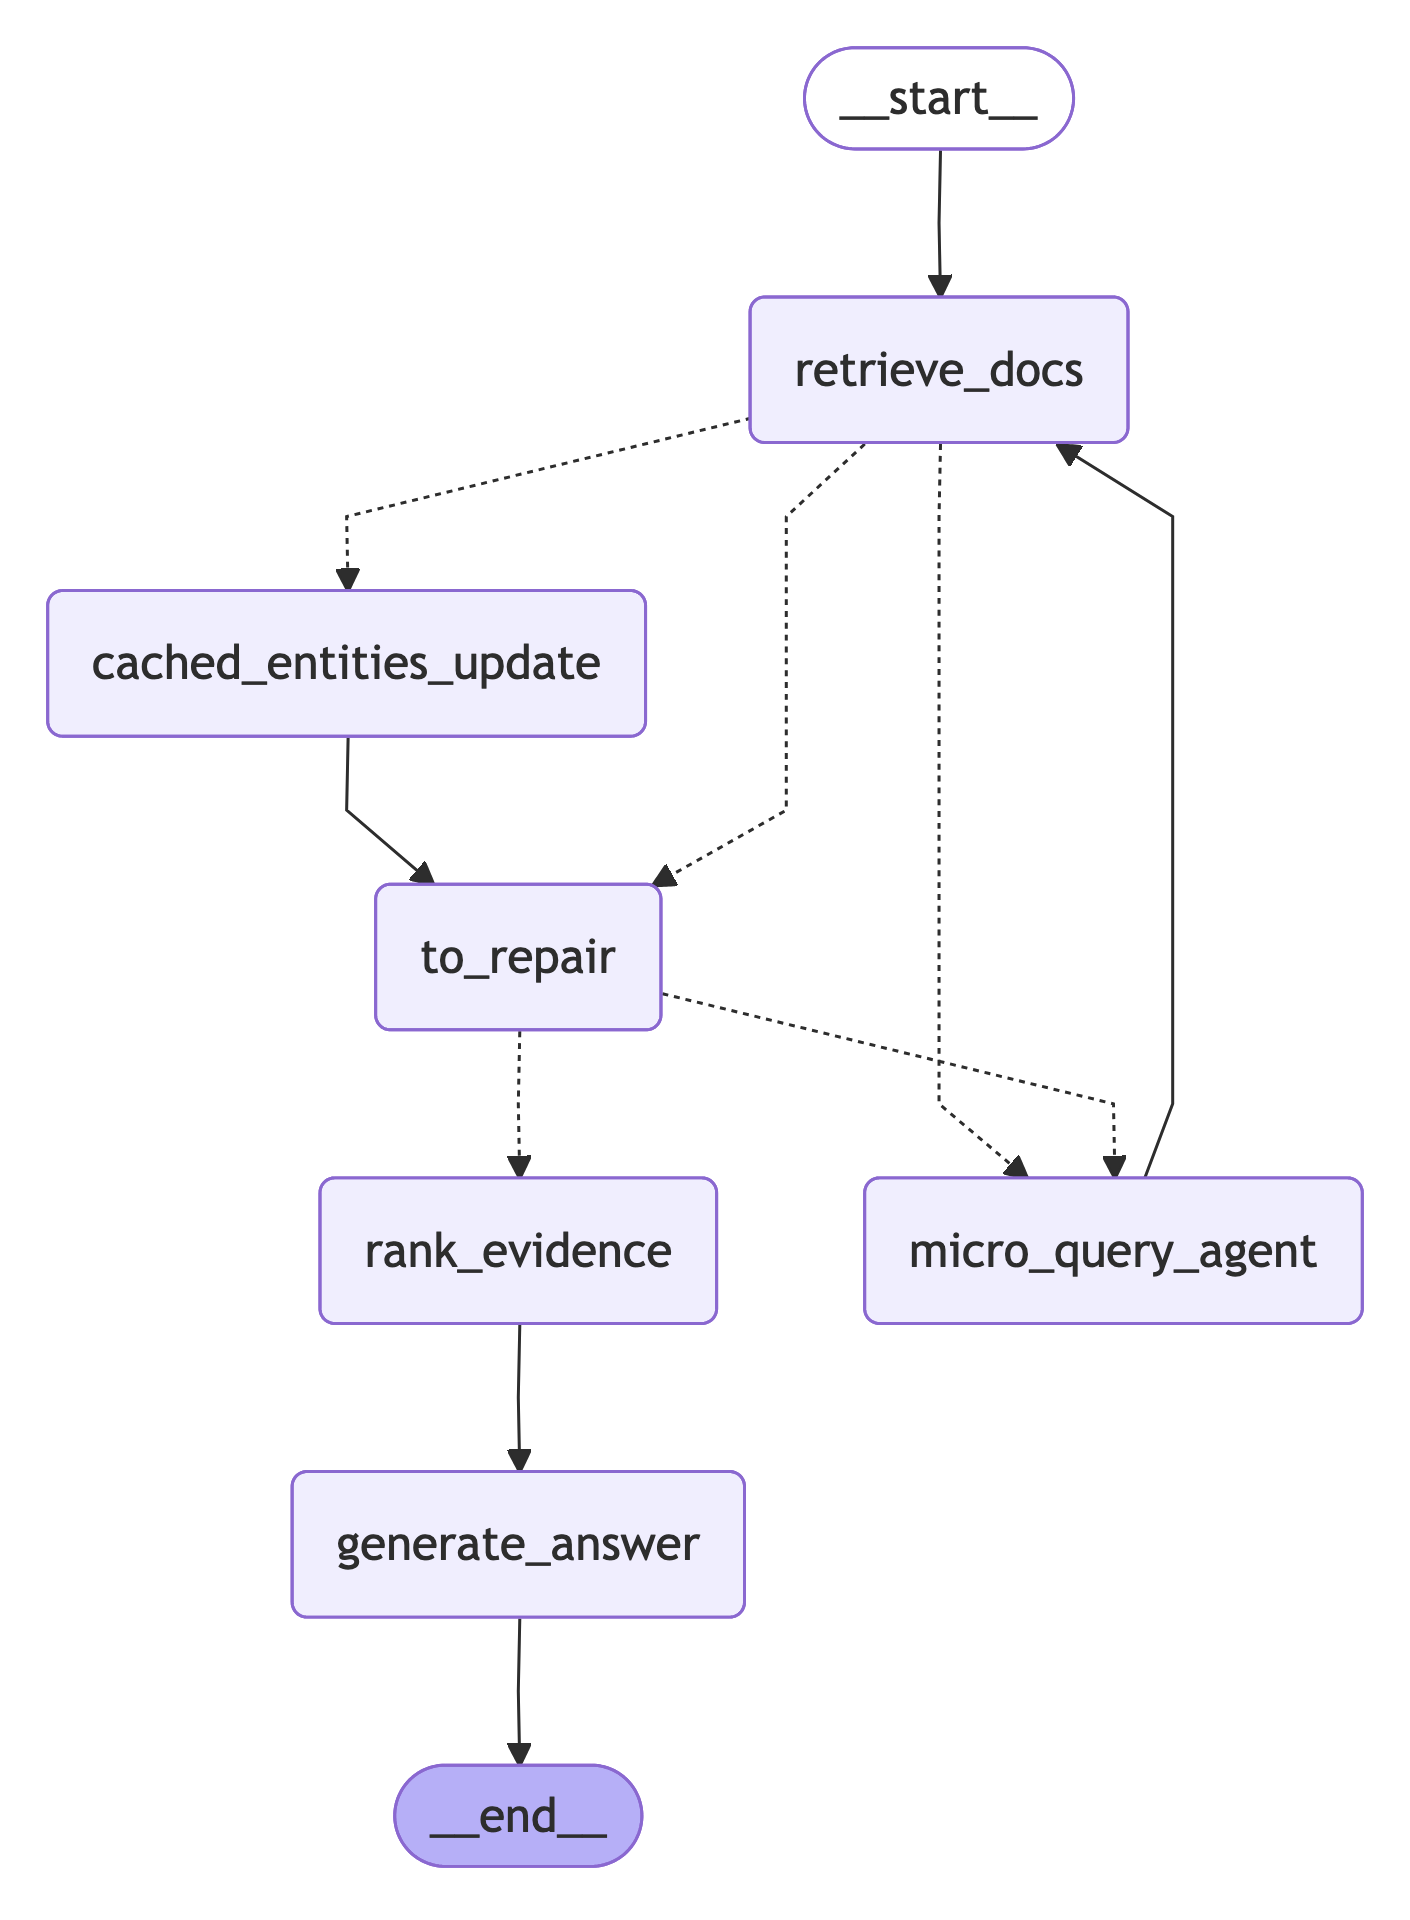

In [2]:
import nest_asyncio
nest_asyncio.apply()  # Allows nested event loops in Jupyter

from IPython.display import Image, display
from langchain_core.runnables.graph import Graph, MermaidDrawMethod


# Render the graph as a PNG image using the local pyppeteer renderer
image_bytes = graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)

# Display the image in the notebook
display(Image(data=image_bytes))

In [4]:
from datasets import load_dataset
#from langcloud import Client  # or from 
from langsmith import Client
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import os
import asyncio
import ast



# ----------------------------
# 1. Create simple LangChain correctness evaluator
# ----------------------------

class EvaluationResult(BaseModel):
    """Evaluation result with reasoning and score."""
    reasoning: str = Field(
        ...,
        description="short explanation of why the answer is correct or incorrect"
    )
    score: bool = Field(
        ...,
        description="True if the answer is correct, False if incorrect"
    )

# Correctness evaluation prompt
correctness_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert data labeler evaluating model outputs for correctness. Your task is to assign a score based on the following rubric:

<Rubric>
  A correct answer:
  - Provides accurate and complete information that matches the ground truth
  - Contains no factual errors when compared to the reference
  - Addresses the core question being asked
  - Is logically consistent with the expected answer
  - Uses precise and accurate terminology
  - May be phrased differently but conveys the same essential meaning as the ground truth

  When scoring, you should penalize:
  - Factual errors or inaccuracies compared to ground truth
  - Answers that contradict the reference output
  - Misleading or ambiguous statements that deviate from truth
  - Completely incorrect or irrelevant responses
  - Missing key information that changes the meaning
  - "I don't know" responses when ground truth provides a clear answer
</Rubric>

<Instructions>
  - Carefully compare the agent's output against the ground truth reference
  - Focus on semantic equivalence rather than exact word matching
  - Consider that correct answers may be expressed in different ways
  - Evaluate factual accuracy and alignment with the expected answer
  - Be lenient with minor phrasing differences if the core meaning matches
  - Be strict with factual contradictions or completely wrong information
</Instructions>

<Reminder>
  The goal is to evaluate how well the agent's final answer aligns with the ground truth, focusing on factual correctness and semantic equivalence rather than exact textual match.
</Reminder>"""),
    ("human", """<question>
{question}
</question>

<agent_output>
{agent_answer}
</agent_output>

<ground_truth>
{ground_truth}
</ground_truth>

Compare the agent's output against the ground truth and evaluate its correctness. Provide your reasoning and a boolean score (true for correct, false for incorrect).""")
])

# Create LLM for evaluation
eval_llm = ChatOpenAI(model="gpt-4o", temperature=0)
structured_eval_llm = eval_llm.with_structured_output(EvaluationResult)

# Create evaluation chain
correctness_evaluator = correctness_prompt | structured_eval_llm



# ----------------------------
# 2. run_graph with progress print
# ----------------------------
async def run_graph(inputs: dict) -> dict:
   
    # Call your RAG graph (replace with your real invocation)
    result = await graph.ainvoke(
        {"user_query": inputs["question"]},
        config={"env": "test", "configurable": {"thread_id": 133}, "recursion_limit": 100}
    )

#    docs = result.get("documents", [])
#    docs = result.get("relevance_documents", "documents")
    docs = result.get("relevance_documents") or result.get("documents", [])


    print(f"docs length: {len(docs) }")

    retrieved = [d.page_content for d in docs]

    #answer = result.get("final_answer", "generation")
    answer = result.get("final_answer") or result.get("generation", "")
    
    return {
        "response":     answer,
        "retrieved_docs_list": retrieved,
        # If your graph later populates docs_to_use, include it in the outputs too
        "docs_to_use":  result.get("docs_to_use", retrieved),
    }

# ----------------------------
# 3. Correctness evaluator wrapper
# ----------------------------
def final_answer_correct(inputs, outputs, reference_outputs) -> bool:
    # Use the LangChain evaluator with structured output
    result = correctness_evaluator.invoke({
        "question": inputs["question"],
        "agent_answer": outputs["response"],
        "ground_truth": reference_outputs["answer"]
    })
    # result is already an EvaluationResult object
    return result.score




# 5. IR‐metric evaluator: Precision@k, Recall@k, F1@k
# ----------------------------

def retrieval_metrics_with_f1(inputs, outputs, reference_outputs) -> list[dict]:
    # parse gold titles
    sf = ast.literal_eval(inputs["supporting_facts"])
    gold = set(sf["title"])

    # normalize & dedupe your retrieved docs
    #retrieved_raw = outputs.get("docs_to_use", outputs["retrieved_docs_list"])
    retrieved_raw = outputs.get("docs_to_use")
    if not retrieved_raw:
        retrieved_raw = outputs.get("docs_to_explain")
    if not retrieved_raw:
        retrieved_raw = outputs.get("retrieved_docs_list", [])


    seen, deduped = set(), []
    for doc in retrieved_raw:
        text = getattr(doc, "page_content", None) or getattr(doc, "content", None) or str(doc)
        title = text.split(":", 1)[0].strip()
        if title not in seen:
            seen.add(title)
            deduped.append(title)

    # true positives
    tp = len(gold & set(deduped))

    # precision (relevance_rate) and recall
    precision = tp / len(deduped)   if deduped else 0.0
    recall    = tp / len(gold)      if gold    else 0.0

    # F1
    if precision + recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
    else:
        f1 = 0.0

    return [
        {"key": "precision",      "score": precision},
        {"key": "recall",         "score": recall},
        {"key": "f1",             "score": f1},
    ]
# ----------------------------
# 5. Assemble and run the experiment
# ----------------------------
client = Client(api_key=os.environ["LANGCHAIN_API_KEY"])


# results = await client.aevaluate(
#     run_graph,
#     data="HotpotQA_1000_validation_hard_v1",
#     evaluators=[final_answer_correct, retrieval_metrics_with_f1],
#     experiment_prefix="seal_rag_k_1_model_gpt-4.1_max_loop_3_v_8",
#     num_repetitions=1,
#     max_concurrency=5,
# )

results = await client.aevaluate(
    run_graph,
    data="2WikiMultihopQA_Validation_200",  # <--- CHANGE THIS
    evaluators=[final_answer_correct, retrieval_metrics_with_f1],
    experiment_prefix="seal_rag_200_k_5_model_4o_loop_1_V1", # <--- CHANGE THIS
    num_repetitions=1,
    max_concurrency=5,
)
df = results.to_pandas()
df




View the evaluation results for experiment: 'seal_rag_200_k_5_model_4o_loop_1_V1-195de113' at:
https://smith.langchain.com/o/b77e783a-1e93-40c4-975b-317ef061487f/datasets/5beb2232-27e4-4643-beb3-7ef2f75804fc/compare?selectedSessions=bee9824e-603f-40f1-a235-10bacacd07d4




0it [00:00, ?it/s]

---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---RETRIEVE---
---CONTINUE TO CACHED ENTITIES UPDATE AGENT------CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 5 documents for cached entities extraction
Original query: What nationality is the director of film World And Time Enough?
Micro query: None
Created 5 Send commands for parallel processing

Dispatching 5 documents for cached entities extraction
Original query: When did Richard Annesley, 2Nd Earl Annesley's father die?
Micro query: None
Created 5 Send commands for parallel processing
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 5 documents for cached entities extraction
Original query: Where was the performer of song God (John Lennon Song) born?
Micro query: None
Created 5 Send commands for parallel processing
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 5 documents for cached entities extraction
Original query: Who died first, Madame Pasca or James A. Donohoe?
Micro query: None
Cre

1it [00:12, 12.21s/it]

---RETRIEVE---
Decision: yes
Reasoning: The core question asks who died first between Madame Pasca and James A. Donohoe. From the entities, Madame Pasca died on May 25, 1914, and James A. Donohoe died on February 26, 1956. Therefore, Madame Pasca died first. The evidence is complete and directly answers the query.
---ROUTING AFTER REPAIR DECISION---
✅ Ready to answer - proceeding to rank_evidence
---RANK EVIDENCE---
---RETRIEVE---
---GENERATE---
---GENERATE---
docs length: 1
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 5 documents for cached entities extraction
Original query: Do Alice Mary Dowd and Richard N. Palmer have the same nationality?
Micro query: None
Created 5 Send commands for parallel processing
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from do

...

docs length: 4
---CONTINUE TO CACHED ENTITIES UPDATE AGENT---
Dispatching 4 documents for cached entities extraction
Original query: Who is the child of the director of film La Leona (Film)?
Micro query: Armando Bo children family
Created 4 Send commands for parallel processing
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...
---CACHED ENTITIES UPDATE (SimpleTriplet)---
Extracting triplets from document (dynamic focus)...


199it [08:43,  2.27s/it]

---TO REPAIR?---
Evaluating repair decision with 3 cached entities and 9 documents
Making repair decision with LLM...
Decision: yes
Reasoning: The core question asks for the child of the director of the film 'La Leona'. From the entities, we know that 'La Leona' is directed by Armando Bó, and Armando Bó's child is Víctor Bó. This provides a complete and direct answer to the query.
---ROUTING AFTER REPAIR DECISION---
✅ Ready to answer - proceeding to rank_evidence
---RANK EVIDENCE---
---GENERATE---
docs length: 2


200it [08:48,  2.64s/it]


,inputs.context,inputs.question,inputs.supporting_facts,outputs.response,outputs.retrieved_docs_list,outputs.docs_to_use,error,reference.answer,feedback.final_answer_correct,feedback.precision,feedback.recall,feedback.f1,execution_time,example_id,id
0,"{'title': ['Caspar Babypants', 'Bernie Bonvois...",Where was the performer of song God (John Lenn...,"{'title': ['God (John Lennon song)', 'John Len...",Liverpool,[John Lennon: John Winston Ono Lennon (born Jo...,[John Lennon: John Winston Ono Lennon (born Jo...,None,Liverpool,True,1.0,0.5,0.666667,11.006564,009279eb-aa2f-4e9a-a388-0570b3d0fad7,99efe15b-d667-4a05-aa96-94de25610a1f
1,"{'title': ['James Woolley (clockmaker)', 'Kase...","Who died first, Madame Pasca or James A. Donohoe?","{'title': ['Madame Pasca', 'James A. Donohoe']...",Madame Pasca.,"[James A. Donohoe: James A. Donohoe( August 9,...","[James A. Donohoe: James A. Donohoe( August 9,...",None,Madame Pasca,True,1.0,1.0,1.000000,13.601051,04491c40-8385-4c7c-9d07-665afd6ef52d,7f290143-e094-4158-870c-baef78393d98
2,"{'title': ['Takayama Tomoteru', 'Anacyndaraxes...",Where was the father of Ștefan I. Nenițescu born?,"{'title': ['Ștefan I. Nenițescu', 'Ioan S. Nen...",Galați,[Ioan S. Nenițescu: Ioan S. Nenițescu (April 1...,[Ioan S. Nenițescu: Ioan S. Nenițescu (April 1...,None,Galați,True,1.0,0.5,0.666667,14.064565,097adb49-d636-4e90-b9cf-ffed265452f6,035c0f97-915c-4ca5-83de-8942e738f232
3,"{'title': ['Richard Annesley, 3rd Baron Altham...","When did Richard Annesley, 2Nd Earl Annesley's...","{'title': ['Richard Annesley, 2nd Earl Annesle...",Before 1802.,"[Richard Annesley, 2nd Earl Annesley: Richard ...","[Richard Annesley, 2nd Earl Annesley: Richard ...",None,2 September 1770,False,1.0,0.5,0.666667,13.319385,002de458-f6e2-4ef7-991f-6c31359ec71c,71580c3d-a2f3-48a6-9341-20c91c51b42c
4,"{'title': ['M. Venkataraju', 'World and Time E...",What nationality is the director of film World...,"{'title': ['World and Time Enough', 'Eric Muel...",I don't know.,[World and Time Enough: World and Time Enough ...,[World and Time Enough: World and Time Enough ...,None,United States,False,1.0,0.5,0.666667,19.110065,01afabb2-0984-4333-bfff-0b3ad45cc593,554e9858-2afe-4fbc-a7cd-9bf095e057e3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,"{'title': ['At the End of the Tunnel', 'Light ...",Where was the director of film At The End Of T...,"{'title': ['At the End of the Tunnel', 'Rodrig...","Rosario, Santa Fe Province.",[At the End of the Tunnel: At the End of the T...,[At the End of the Tunnel: At the End of the T...,None,Rosario,True,1.0,1.0,1.000000,15.347683,f93273dc-9a7c-49e6-b51c-887b2f6b3293,e6e4573c-f04f-448f-8547-0354f5717822
196,"{'title': ['Isipum of Geumgwan Gaya', 'Queen M...",What nationality is Geodeung Of Geumgwan Gaya'...,"{'title': ['Geodeung of Geumgwan Gaya', 'Heo H...",Likely Indian.,"[Geodeung of Geumgwan Gaya: Geodeung of Gaya, ...","[Geodeung of Geumgwan Gaya: Geodeung of Gaya, ...",None,India,False,1.0,1.0,1.000000,9.219079,fd8c17b6-5955-4adc-911f-a3d54ab6487e,e28beb6e-2293-4d45-991a-a3f59202dc21
197,"{'title': ['Control engineering', 'Information...","Are both businesses, Telus and Ztr Control Sys...","{'title': ['Telus', 'ZTR Control Systems'], 's...","Yes, in Canada.",[ZTR Control Systems: ZTR Control Systems is a...,[ZTR Control Systems: ZTR Control Systems is a...,None,yes,True,1.0,1.0,1.000000,8.722941,fd41bcf3-aeb3-4d4e-80f7-580d7864172a,1b5fbe22-465d-4dcd-bf32-1f500d0c2c30
198,"{'title': ['Jayam Manade', 'Bulldog Drummond (...","Which film has the director born earlier, Jaya...","{'title': ['Jayam Manade', ""Bulldog Drummond's...",Bulldog Drummond's Revenge,[Jayam Manade: Jayam Manade is a 1956 Telugu l...,[Jayam Manade: Jayam Manade is a 1956 Telugu l...,None,Bulldog Drummond'S Revenge,True,1.0,1.0,1.000000,16.366360,fc9ea4fb-5063-4d64-9bd3-e52efb03ecbe,dc036469-0bda-43e4-b1d1-ca5feab291e8


In [9]:
df.head()

,inputs.context,inputs.question,inputs.supporting_facts,outputs.response,outputs.retrieved_docs_list,outputs.docs_to_use,error,reference.answer,feedback.final_answer_correct,feedback.precision,feedback.recall,feedback.f1,execution_time,example_id,id,outputs.output,feedback.wrapper
0,"{'title': ['Enda Kenny', 'Fine Gael leadership...","Since 2 June 2017, The Leader of Fine Gael had...","{'title': ['Leader of Fine Gael', 'Leo Varadka...","Since 2 June 2017, the Leader of Fine Gael has...",[Enda Kenny: Enda Patrick Kenny (born 24 April...,[Enda Kenny: Enda Patrick Kenny (born 24 April...,None,Leo Varadkar,True,0.666667,1.0,0.8,7.662598,01890c6a-a3ea-4cf0-8514-e469c2e46032,c2757b21-dc5b-4eb6-b8c7-f3ce4c19d7eb,NaN,NaN
1,"{'title': ['Ralph Charles', 'Bunny Grant', 'Vi...",Vince Phillips held a junior welterweight titl...,"{'title': ['Vince Phillips', 'International Bo...",The larger Hall of Fame that recognizes the In...,[International Boxing Federation: The Internat...,[International Boxing Federation: The Internat...,None,International Boxing Hall of Fame,True,0.500000,0.5,0.5,10.946834,0354d139-82d6-416d-a698-99b070598b57,c4b3a1fb-4382-4db9-9fe4-8bbb68435e58,NaN,NaN
2,"{'title': ['2009 Singapore Grand Prix', 'Catha...",Which other Mexican Formula One race car drive...,"{'title': ['Formula One drivers from Mexico', ...","The other Mexican Formula One driver, besides ...",[Formula One drivers from Mexico: There have b...,[Formula One drivers from Mexico: There have b...,None,Pedro Rodríguez,True,0.500000,0.5,0.5,12.259177,04dd6118-3990-48ef-9d5f-18dec47283fe,b54edfec-8a0f-477e-a060-ed7d917df44e,NaN,NaN
3,"{'title': [""It's Alive! (Dexter)"", 'Hello, Dex...",Who were the directors of the 2009 American sc...,"{'title': ['Gamer (film)', 'Michael C. Hall'],...","The 2009 American sci-fi film ""Gamer,"" featuri...",[Gamer is a 2009 American science fiction acti...,[Gamer is a 2009 American science fiction acti...,None,Mark Neveldine and Brian Taylor,True,0.000000,0.0,0.0,11.559350,032e3f0c-7622-4ae7-a0be-49361a664c60,6503595b-dbca-4851-a91e-2f1a24b3aa2c,NaN,NaN
4,"{'title': ['Maltin on Movies', 'Comedy Film Ne...",What podcast was the cheif executive officer o...,"{'title': ['Comedy Film Nerds', 'Comedy Film N...","The CEO of Nerdist Industries, Chris Hardwick,...","[Founder, CEO and creative head of Nerdist Ind...","[Founder, CEO and creative head of Nerdist Ind...",None,Comedy Film Nerds,False,0.000000,0.0,0.0,12.506101,011e87e0-185f-4dcc-8cce-2d6dde0fca2c,76667303-f433-4bc9-92b8-cf96be348738,NaN,NaN


In [11]:
df.iloc[0]

inputs.context                   {'title': ['Enda Kenny', 'Fine Gael leadership...
inputs.question                  Since 2 June 2017, The Leader of Fine Gael had...
inputs.supporting_facts          {'title': ['Leader of Fine Gael', 'Leo Varadka...
outputs.response                 Since 2 June 2017, the Leader of Fine Gael has...
outputs.retrieved_docs_list      [Enda Kenny: Enda Patrick Kenny (born 24 April...
outputs.docs_to_use              [Enda Kenny: Enda Patrick Kenny (born 24 April...
error                                                                         None
reference.answer                                                      Leo Varadkar
feedback.final_answer_correct                                                 True
feedback.precision                                                        0.666667
feedback.recall                                                                1.0
feedback.f1                                                                    0.8
exec